# Questão 3

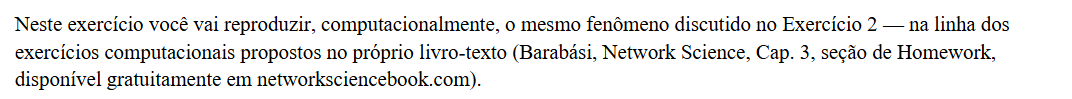

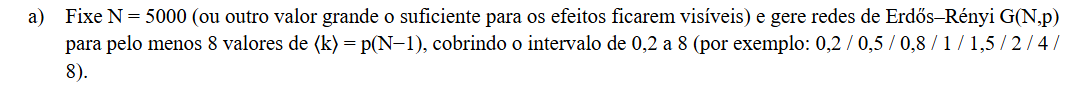

In [19]:
import networkx as nx 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [20]:
k_values = [0.2,0.5,0.8,1,1.5,2,4,8]
p_values = [i / 4999 for i in k_values]

networks = [nx.erdos_renyi_graph(5000,p) for p in p_values]

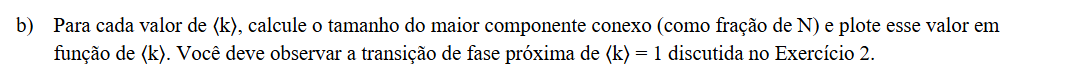

In [21]:
lcc = [len(max(nx.connected_components(G), key=lambda x: len(x))) / 5000 for G in networks] # lcc stands for Largest Connected Component

result = pd.DataFrame({
    "K": k_values,
    "lcc": lcc
})

In [22]:
result

,K,lcc
0,0.2,0.0010
1,0.5,0.0022
2,0.8,0.0156
3,1.0,0.0652
4,1.5,0.5714
5,2.0,0.7960
6,4.0,0.9804
7,8.0,0.9998


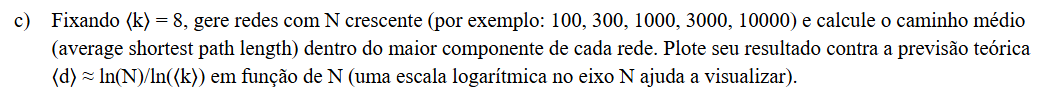

In [23]:
N_values = [100,300,1000,2000,5000]
p_values = [8 / (n-1) for n in N_values]

networks = [nx.erdos_renyi_graph(N_values[i], p_values[i]) for i in range(len(N_values))]

ccs = [G.subgraph(max(nx.connected_components(G), key=len)) for G in networks]
avs = [nx.average_shortest_path_length(cc) for cc in ccs]

result = pd.DataFrame({
    "N": N_values,
    "avs": avs
})

In [24]:
result

,N,avs
0,100,2.421818
1,300,2.960557
2,1000,3.498717
3,2000,3.899269
4,5000,4.328892


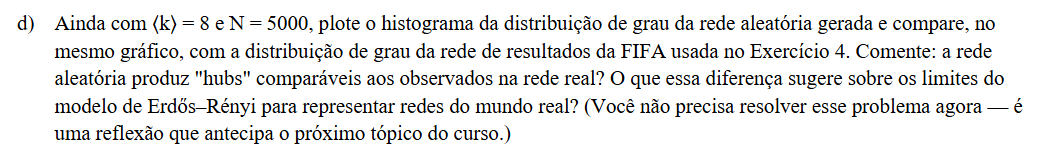

In [25]:
Erdos = nx.erdos_renyi_graph(5000, 8/4999)

df = pd.read_csv("football_edges_filtered.csv")

FIFA = nx.from_pandas_edgelist(
    df,
    source='source',
    target='target',
    edge_attr='weight',
    create_using=nx.DiGraph())

Erdos_dist = [v for _, v in Erdos.degree()]
FIFA_dist = [v for _, v in FIFA.degree()]

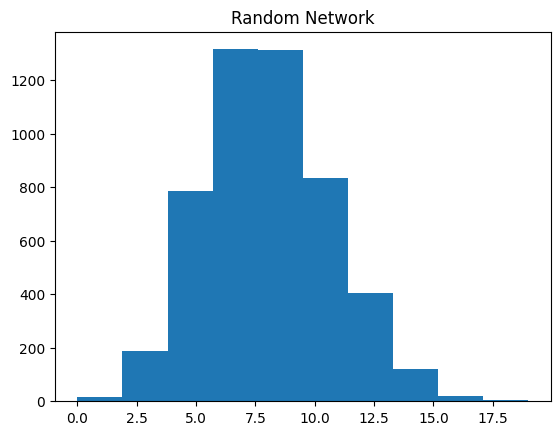

In [26]:
plt.hist(Erdos_dist)
plt.title("Random Network")
plt.show()

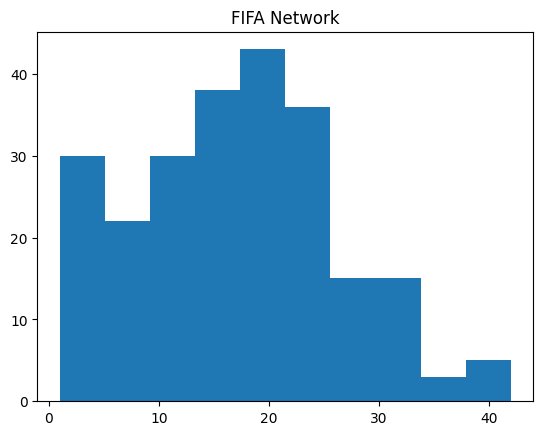

In [27]:
plt.hist(FIFA_dist)
plt.title("FIFA Network")
plt.show()

Não. A rede aleatória não produz hubs comparáveis, por ser modelada por uma distribuição de poisson os nós nunca tem graus muito distantes da média, diferentemente da distriuição real da fifa que tem seleções com um grau muito mais distante do grau médio em relação à rede aleatória.